## width 3, inset+floor


Loading Random from: plot_a_files/t0to50_table.txt
Random: 10000 samples
Random: mean complexity_entropy = 24.899

Loading Whole_space from: plot_a_files/compiled_0mut.txt
Whole_space: 5369 samples
Whole_space: mean complexity_entropy = 29.877

Data range: 5.640 → 47.970

Bin width = 3.0
Number of bins = 15
Epsilon floor value = 1.863e-05


/var/folders/yr/bzwkxpcj34x73kc2trlk0h2m0000gn/T/ipykernel_98013/1451216046.py:161: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


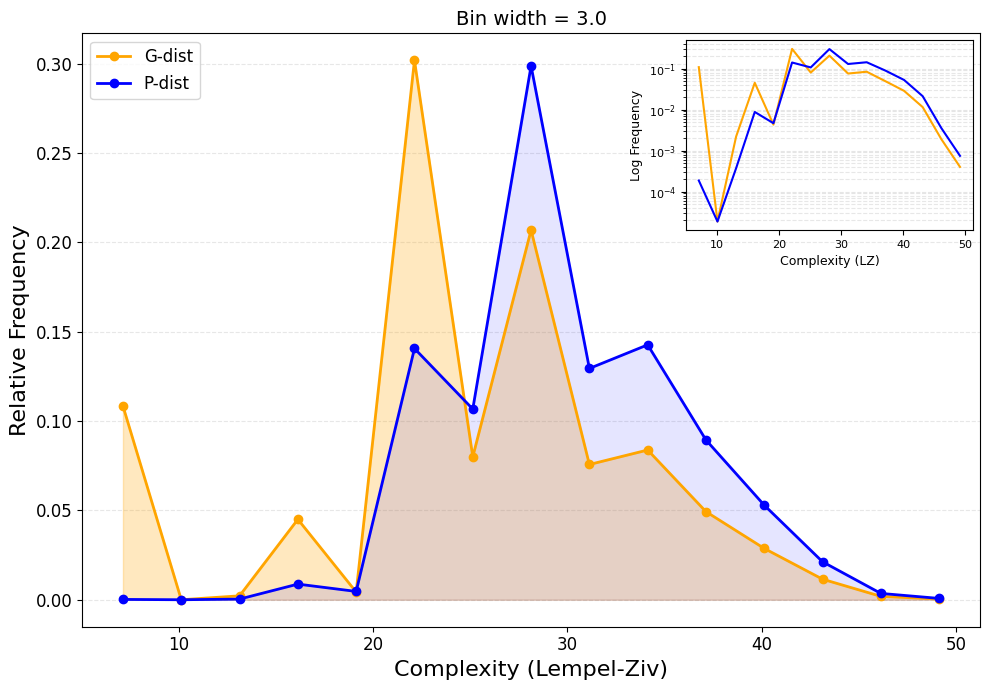

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ===================================
# Configuration
# ===================================
base_dir = Path("./plot_a_files")
file_path_rand = base_dir / "t0to50_table.txt"
file_path_0_mut = base_dir / "compiled_0mut.txt"
phenotype_length = 50

# ===================================

def load_dataset(file_path, name):
    print(f"\nLoading {name} from: {file_path}")

    if not file_path.exists():
        raise FileNotFoundError(f"{file_path} not found")

    df = pd.read_csv(file_path, sep="\t")

    if df.columns[0].startswith("#"):
        df = pd.read_csv(
            file_path,
            sep="\t",
            skiprows=1,
            names=["file_number",
                   "genotype_raw",
                   "phenotype_binary",
                   "complexity_entropy"]
        )

    df["phenotype_binary"] = df["phenotype_binary"].astype(str)
    df["phenotype_length"] = df["phenotype_binary"].str.len()

    df_filtered = df[df["phenotype_length"] == phenotype_length]

    complexities = df_filtered["complexity_entropy"].astype(float).values
    complexities = complexities[complexities > 0]

    print(f"{name}: {len(complexities)} samples")
    print(f"{name}: mean complexity_entropy = {complexities.mean():.3f}")

    return complexities


# ===================================
# Load data
# ===================================
rand_raw = load_dataset(file_path_rand, "Random")
zero_raw = load_dataset(file_path_0_mut, "Whole_space")

all_data = np.concatenate([rand_raw, zero_raw])
min_val = all_data.min()
max_val = all_data.max()

print(f"\nData range: {min_val:.3f} → {max_val:.3f}")

# ===================================
# Fixed bin width
# ===================================
bin_width = 3.0
bins = np.arange(min_val, max_val + bin_width, bin_width)
n_bins = len(bins) - 1

print(f"\nBin width = {bin_width}")
print(f"Number of bins = {n_bins}")

# Histogram
rand_counts, bin_edges = np.histogram(rand_raw, bins=bins, density=False)
zero_counts, _ = np.histogram(zero_raw, bins=bins, density=False)

# Normalize to PMF
rand_counts = rand_counts / rand_counts.sum()
zero_counts = zero_counts / zero_counts.sum()

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# ===================================
# Adaptive epsilon floor (log inset)
# ===================================
all_nonzero = np.concatenate([
    rand_counts[rand_counts > 0],
    zero_counts[zero_counts > 0]
])

eps = np.min(all_nonzero) * 0.1
print(f"Epsilon floor value = {eps:.3e}")

rand_safe = np.clip(rand_counts, eps, None)
zero_safe = np.clip(zero_counts, eps, None)

# ===================================
# Plot
# ===================================
fig, ax = plt.subplots(figsize=(10, 7))

# ---- G-dist ----
ax.plot(bin_centers,
        rand_counts,
        marker='o',
        linewidth=2,
        color="orange",
        label="G-dist")

ax.fill_between(bin_centers,
                rand_counts,
                0,
                color="orange",
                alpha=0.25)

# ---- P-dist ----
ax.plot(bin_centers,
        zero_counts,
        marker='o',
        linewidth=2,
        color="blue",
        label="P-dist")

ax.fill_between(bin_centers,
                zero_counts,
                0,
                color="blue",
                alpha=0.1)

ax.set_xlabel("Complexity (Lempel-Ziv)", fontsize=16)
ax.set_ylabel("Relative Frequency", fontsize=16)
ax.set_title(f"Bin width = {bin_width}", fontsize=14)

ax.legend(fontsize=12, loc="upper left")
ax.tick_params(labelsize=12)
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.set_axisbelow(True)

# ===================================
# Inset (log–y with floor)
# ===================================
ax_inset = inset_axes(ax, width="32%", height="32%", loc="upper right")

ax_inset.plot(bin_centers,
              rand_safe,
              linewidth=1.5,
              color="orange")

ax_inset.plot(bin_centers,
              zero_safe,
              linewidth=1.5,
              color="blue")

ax_inset.set_yscale("log")
ax_inset.set_xlabel("Complexity (LZ)", fontsize=9)
ax_inset.set_ylabel("Log Frequency", fontsize=9)

ax_inset.tick_params(labelsize=8)
ax_inset.grid(which="both", axis="y", alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

## Polygon, 30 bins, inset=markers


Loading Random from: plot_a_files/t0to50_table.txt
Random: 10000 samples
Random: mean complexity_entropy = 24.899

Loading Whole_space from: plot_a_files/compiled_0mut.txt
Whole_space: 5369 samples
Whole_space: mean complexity_entropy = 29.877


/var/folders/yr/bzwkxpcj34x73kc2trlk0h2m0000gn/T/ipykernel_41417/3676739691.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


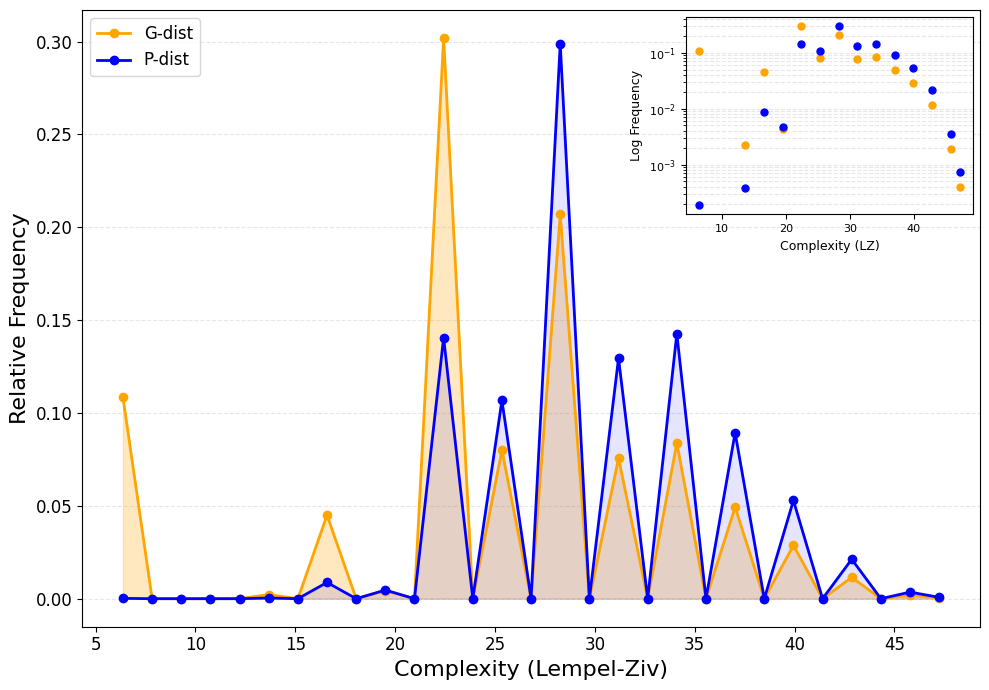

In [79]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ===================================
# Configuration
# ===================================
base_dir = Path("./plot_a_files")
file_path_rand = base_dir / "t0to50_table.txt"
file_path_0_mut = base_dir / "compiled_0mut.txt"
phenotype_length = 50
n_bins = 30
# ===================================

def load_dataset(file_path, name):
    print(f"\nLoading {name} from: {file_path}")

    if not file_path.exists():
        raise FileNotFoundError(f"{file_path} not found")

    df = pd.read_csv(file_path, sep="\t")

    if df.columns[0].startswith("#"):
        df = pd.read_csv(
            file_path,
            sep="\t",
            skiprows=1,
            names=["file_number",
                   "genotype_raw",
                   "phenotype_binary",
                   "complexity_entropy"]
        )

    if "complexity_entropy" not in df.columns:
        raise ValueError(f"'complexity_entropy' not found in {name}")

    df["phenotype_binary"] = df["phenotype_binary"].astype(str)
    df["phenotype_length"] = df["phenotype_binary"].str.len()

    df_filtered = df[df["phenotype_length"] == phenotype_length]

    complexities = df_filtered["complexity_entropy"].astype(float).values
    complexities = complexities[complexities > 0]

    print(f"{name}: {len(complexities)} samples")
    print(f"{name}: mean complexity_entropy = {complexities.mean():.3f}")

    return complexities


# ===================================
# Load data
# ===================================

rand_raw = load_dataset(file_path_rand, "Random")
zero_raw = load_dataset(file_path_0_mut, "Whole_space")

# ===================================
# Linear bins (22 bins)
# ===================================

all_data = np.concatenate([rand_raw, zero_raw])
min_val = all_data.min()
max_val = all_data.max()

bins = np.linspace(min_val, max_val, n_bins)

# ===================================
# PMF normalization (heights sum to 1)
# ===================================

rand_counts, bin_edges = np.histogram(rand_raw, bins=bins, density=False)
zero_counts, _ = np.histogram(zero_raw, bins=bins, density=False)

rand_counts = rand_counts / rand_counts.sum()
zero_counts = zero_counts / zero_counts.sum()

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# ===================================
# Main Plot (shaded frequency polygon)
# ===================================

fig, ax = plt.subplots(figsize=(10, 7))

# ---- G-dist ----
ax.plot(bin_centers,
        rand_counts,
        marker='o',
        linewidth=2,
        color="orange",
        label="G-dist")

ax.fill_between(bin_centers,
                rand_counts,
                0,
                color="orange",
                alpha=0.25)

# ---- P-dist ----
ax.plot(bin_centers,
        zero_counts,
        marker='o',
        linewidth=2,
        color="blue",
        label="P-dist")

ax.fill_between(bin_centers,
                zero_counts,
                0,
                color="blue",
                alpha=0.1)

ax.set_xlabel("Complexity (Lempel-Ziv)", fontsize=16)
ax.set_ylabel("Relative Frequency", fontsize=16)

ax.legend(fontsize=12, loc="upper left")
ax.tick_params(labelsize=12)
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.set_axisbelow(True)

# =========================
# Inset Panel (log-y, markers-only)
# =========================
ax_inset = inset_axes(ax, width="32%", height="32%", loc="upper right")

# mask nonzero bins
mask_rand = rand_counts > 0
mask_zero = zero_counts > 0

# plot markers only (no connecting lines)
ax_inset.plot(bin_centers[mask_rand],
              rand_counts[mask_rand],
              marker='o',
              linestyle='',
              markersize=5,
              color="orange",
              label="G-dist")

ax_inset.plot(bin_centers[mask_zero],
              zero_counts[mask_zero],
              marker='o',
              linestyle='',
              markersize=5,
              color="blue",
              label="P-dist")

ax_inset.set_yscale("log")
ax_inset.set_xlabel("Complexity (LZ)", fontsize=9)
ax_inset.set_ylabel("Log Frequency", fontsize=9)
ax_inset.tick_params(labelsize=8)
ax_inset.grid(which="both", axis="y", alpha=0.3, linestyle="--")

# ===================================

plt.tight_layout()
plt.show()

### inset = sticks


Loading Random from: plot_a_files/t0to50_table.txt
Random: 10000 samples
Random: mean complexity_entropy = 24.899

Loading Whole_space from: plot_a_files/compiled_0mut.txt
Whole_space: 5369 samples
Whole_space: mean complexity_entropy = 29.877


/var/folders/yr/bzwkxpcj34x73kc2trlk0h2m0000gn/T/ipykernel_41417/4254067163.py:156: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


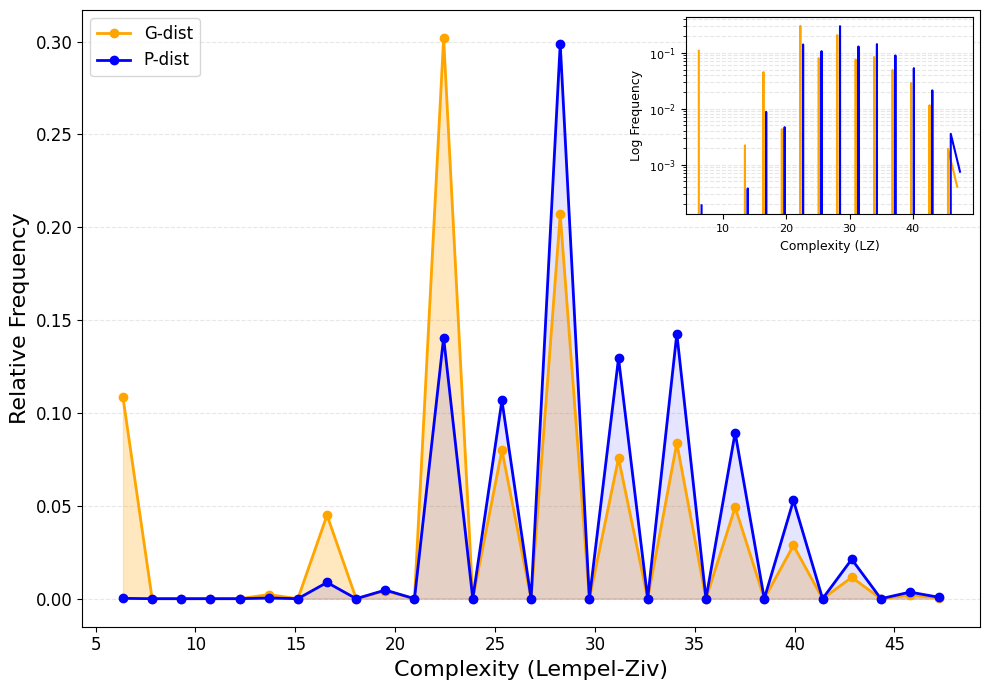

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ===================================
# Configuration
# ===================================
base_dir = Path("./plot_a_files")
file_path_rand = base_dir / "t0to50_table.txt"
file_path_0_mut = base_dir / "compiled_0mut.txt"
phenotype_length = 50
n_bins = 30
# ===================================

def load_dataset(file_path, name):
    print(f"\nLoading {name} from: {file_path}")

    if not file_path.exists():
        raise FileNotFoundError(f"{file_path} not found")

    df = pd.read_csv(file_path, sep="\t")

    if df.columns[0].startswith("#"):
        df = pd.read_csv(
            file_path,
            sep="\t",
            skiprows=1,
            names=["file_number",
                   "genotype_raw",
                   "phenotype_binary",
                   "complexity_entropy"]
        )

    if "complexity_entropy" not in df.columns:
        raise ValueError(f"'complexity_entropy' not found in {name}")

    df["phenotype_binary"] = df["phenotype_binary"].astype(str)
    df["phenotype_length"] = df["phenotype_binary"].str.len()

    df_filtered = df[df["phenotype_length"] == phenotype_length]

    complexities = df_filtered["complexity_entropy"].astype(float).values
    complexities = complexities[complexities > 0]

    print(f"{name}: {len(complexities)} samples")
    print(f"{name}: mean complexity_entropy = {complexities.mean():.3f}")

    return complexities


# ===================================
# Load data
# ===================================

rand_raw = load_dataset(file_path_rand, "Random")
zero_raw = load_dataset(file_path_0_mut, "Whole_space")

# ===================================
# Linear bins (22 bins)
# ===================================

all_data = np.concatenate([rand_raw, zero_raw])
min_val = all_data.min()
max_val = all_data.max()

bins = np.linspace(min_val, max_val, n_bins)

# ===================================
# PMF normalization (heights sum to 1)
# ===================================

rand_counts, bin_edges = np.histogram(rand_raw, bins=bins, density=False)
zero_counts, _ = np.histogram(zero_raw, bins=bins, density=False)

rand_counts = rand_counts / rand_counts.sum()
zero_counts = zero_counts / zero_counts.sum()

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# ===================================
# Main Plot (shaded frequency polygon)
# ===================================

fig, ax = plt.subplots(figsize=(10, 7))

# ---- G-dist ----
ax.plot(bin_centers,
        rand_counts,
        marker='o',
        linewidth=2,
        color="orange",
        label="G-dist")

ax.fill_between(bin_centers,
                rand_counts,
                0,
                color="orange",
                alpha=0.25)

# ---- P-dist ----
ax.plot(bin_centers,
        zero_counts,
        marker='o',
        linewidth=2,
        color="blue",
        label="P-dist")

ax.fill_between(bin_centers,
                zero_counts,
                0,
                color="blue",
                alpha=0.1)

ax.set_xlabel("Complexity (Lempel-Ziv)", fontsize=16)
ax.set_ylabel("Relative Frequency", fontsize=16)

ax.legend(fontsize=12, loc="upper left")
ax.tick_params(labelsize=12)
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.set_axisbelow(True)

# ===================================
# Inset Panel (log–y, slight x-offset)
# ===================================

ax_inset = inset_axes(ax, width="32%", height="32%", loc="upper right")

# Compute small horizontal offset relative to bin spacing
bin_spacing = bin_centers[1] - bin_centers[0]
#offset = 0.15 * bin_spacing   # adjust 0.10–0.20 if needed

# Plot shifted curves
ax_inset.plot(bin_centers,
              rand_counts,
              linewidth=1.5,
              color="orange")

ax_inset.plot(bin_centers,
              zero_counts,
              linewidth=1.5,
              color="blue")

ax_inset.set_yscale("log")

ax_inset.set_xlabel("Complexity (LZ)", fontsize=9)
ax_inset.set_ylabel("Log Frequency", fontsize=9)

ax_inset.tick_params(labelsize=8)
ax_inset.grid(which="both", axis="y", alpha=0.3, linestyle="--")

# ===================================

plt.tight_layout()
plt.show()

vary bin width


Loading Random from: plot_a_files/t0to50_table.txt
Random: 10000 samples
Random: mean complexity_entropy = 24.899

Loading Whole_space from: plot_a_files/compiled_0mut.txt
Whole_space: 5369 samples
Whole_space: mean complexity_entropy = 29.877

Bin width = 0.50


/var/folders/yr/bzwkxpcj34x73kc2trlk0h2m0000gn/T/ipykernel_98013/497237538.py:150: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


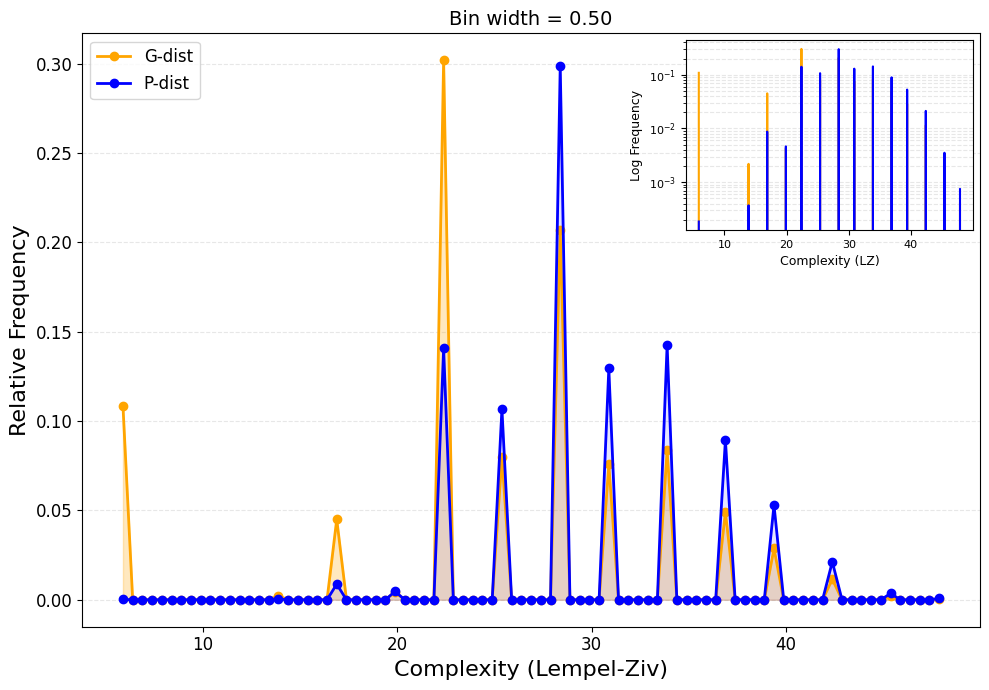


Bin width = 1.00


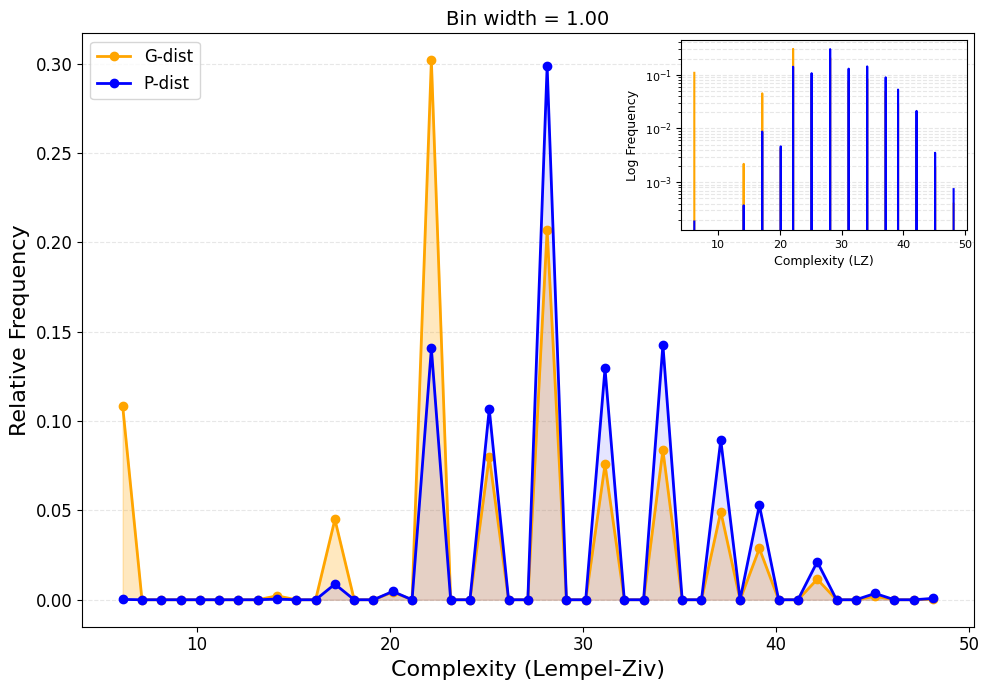


Bin width = 1.50


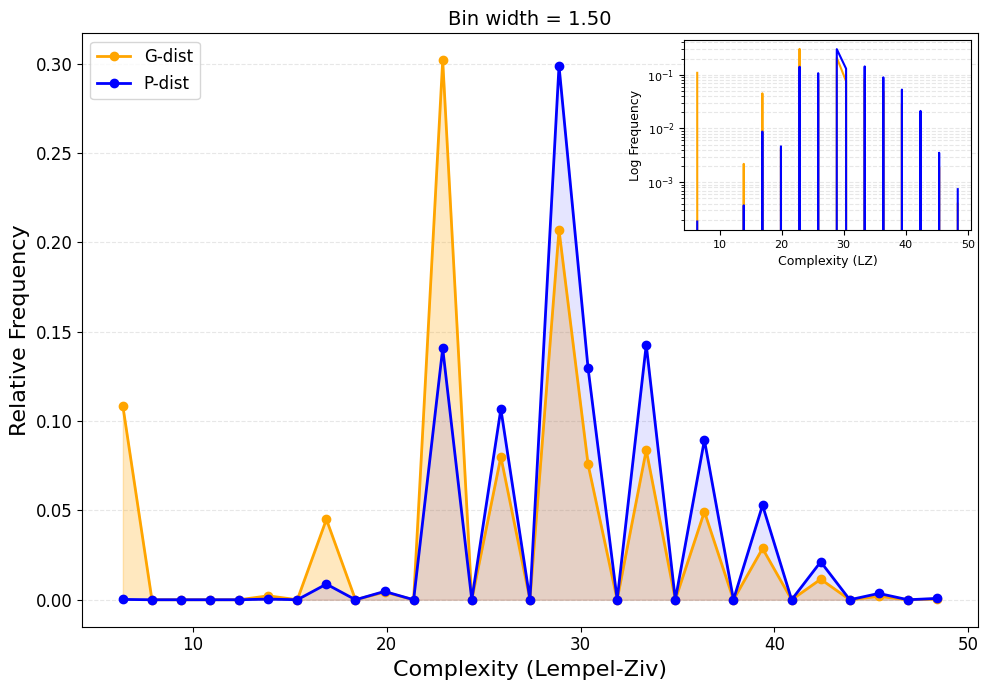


Bin width = 2.00


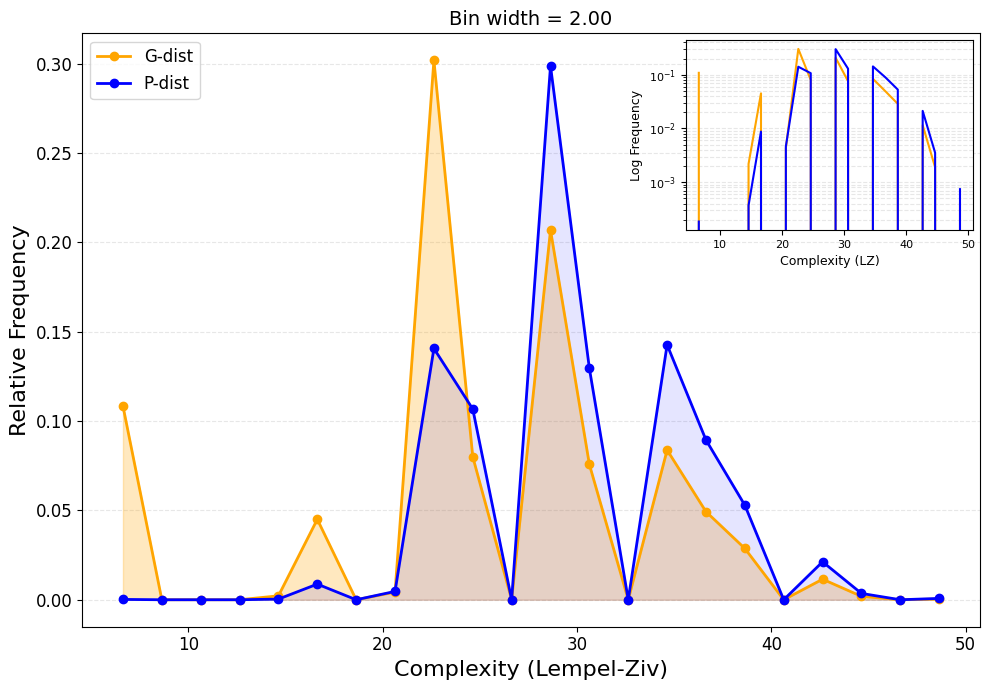


Bin width = 2.50


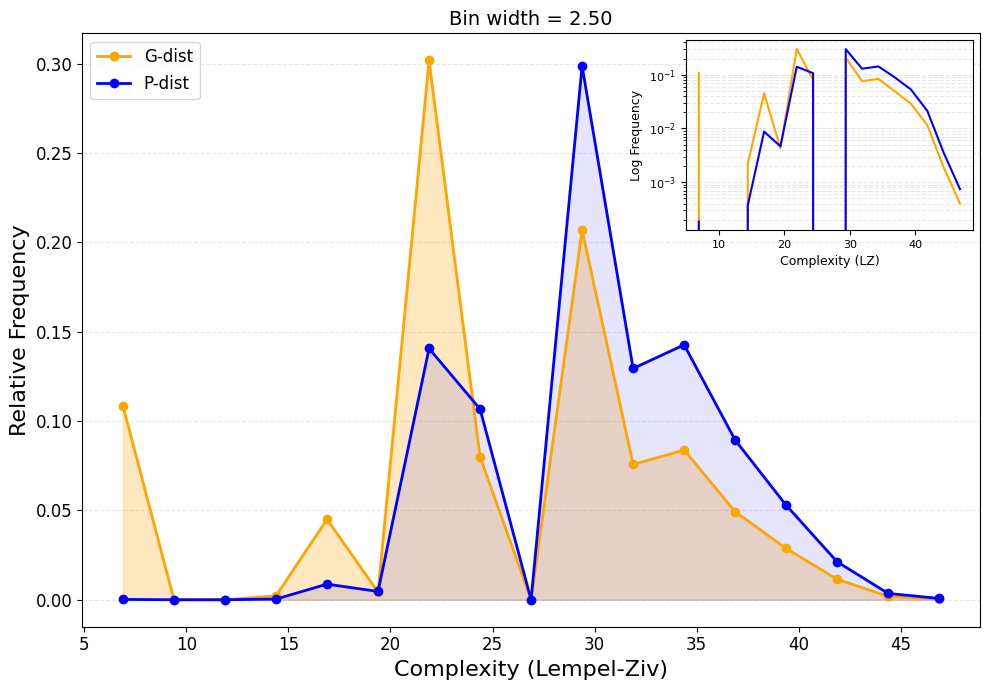


Bin width = 3.00


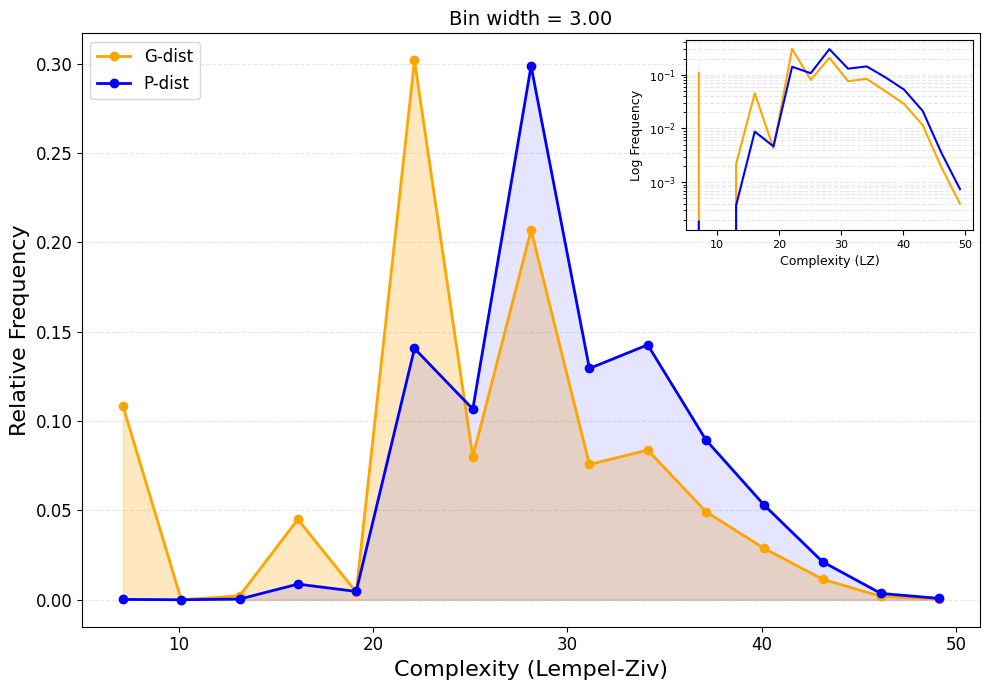

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ===================================
# Configuration
# ===================================
base_dir = Path("./plot_a_files")
file_path_rand = base_dir / "t0to50_table.txt"
file_path_0_mut = base_dir / "compiled_0mut.txt"
phenotype_length = 50

# ===================================

def load_dataset(file_path, name):
    print(f"\nLoading {name} from: {file_path}")

    if not file_path.exists():
        raise FileNotFoundError(f"{file_path} not found")

    df = pd.read_csv(file_path, sep="\t")

    if df.columns[0].startswith("#"):
        df = pd.read_csv(
            file_path,
            sep="\t",
            skiprows=1,
            names=["file_number",
                   "genotype_raw",
                   "phenotype_binary",
                   "complexity_entropy"]
        )

    if "complexity_entropy" not in df.columns:
        raise ValueError(f"'complexity_entropy' not found in {name}")

    df["phenotype_binary"] = df["phenotype_binary"].astype(str)
    df["phenotype_length"] = df["phenotype_binary"].str.len()

    df_filtered = df[df["phenotype_length"] == phenotype_length]

    complexities = df_filtered["complexity_entropy"].astype(float).values
    complexities = complexities[complexities > 0]

    print(f"{name}: {len(complexities)} samples")
    print(f"{name}: mean complexity_entropy = {complexities.mean():.3f}")

    return complexities


# ===================================
# Load data
# ===================================

rand_raw = load_dataset(file_path_rand, "Random")
zero_raw = load_dataset(file_path_0_mut, "Whole_space")

all_data = np.concatenate([rand_raw, zero_raw])
min_val = all_data.min()
max_val = all_data.max()

# ===================================
# Loop over bin widths
# ===================================

for bin_width in np.arange(0.5, 3.1, 0.5):

    print(f"\nBin width = {bin_width:.2f}")

    bins = np.arange(min_val, max_val + bin_width, bin_width)

    rand_counts, bin_edges = np.histogram(rand_raw, bins=bins, density=False)
    zero_counts, _ = np.histogram(zero_raw, bins=bins, density=False)

    # Normalize to PMF
    rand_counts = rand_counts / rand_counts.sum()
    zero_counts = zero_counts / zero_counts.sum()

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # ===================================
    # Plot
    # ===================================

    fig, ax = plt.subplots(figsize=(10, 7))

    # ---- G-dist ----
    ax.plot(bin_centers,
            rand_counts,
            marker='o',
            linewidth=2,
            color="orange",
            label="G-dist")

    ax.fill_between(bin_centers,
                    rand_counts,
                    0,
                    color="orange",
                    alpha=0.25)

    # ---- P-dist ----
    ax.plot(bin_centers,
            zero_counts,
            marker='o',
            linewidth=2,
            color="blue",
            label="P-dist")

    ax.fill_between(bin_centers,
                    zero_counts,
                    0,
                    color="blue",
                    alpha=0.1)

    ax.set_xlabel("Complexity (Lempel-Ziv)", fontsize=16)
    ax.set_ylabel("Relative Frequency", fontsize=16)
    ax.set_title(f"Bin width = {bin_width:.2f}", fontsize=14)

    ax.legend(fontsize=12, loc="upper left")
    ax.tick_params(labelsize=12)
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.set_axisbelow(True)

    # ===================================
    # Inset Panel (log–y)
    # ===================================

    ax_inset = inset_axes(ax, width="32%", height="32%", loc="upper right")

    ax_inset.plot(bin_centers,
                  rand_counts,
                  linewidth=1.5,
                  color="orange")

    ax_inset.plot(bin_centers,
                  zero_counts,
                  linewidth=1.5,
                  color="blue")

    ax_inset.set_yscale("log")
    ax_inset.set_xlabel("Complexity (LZ)", fontsize=9)
    ax_inset.set_ylabel("Log Frequency", fontsize=9)

    ax_inset.tick_params(labelsize=8)
    ax_inset.grid(which="both", axis="y", alpha=0.3, linestyle="--")

    plt.tight_layout()
    plt.show()